In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

# Check first dataset
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
# Check shape of both datasets
print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

# Check columns
print("\nDataset 1 columns:", df1.columns.tolist())
print("\nDataset 2 columns:", df2.columns.tolist())

Dataset 1 shape: (768, 7)
Dataset 2 shape: (267, 9)

Dataset 1 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset 2 columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [6]:
# Clean column names (remove extra spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Check for missing values
print("Dataset 1 missing values:")
print(df1.isnull().sum())
print("\nDataset 2 missing values:")
print(df2.isnull().sum())

Dataset 1 missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Dataset 2 missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [7]:
# Drop missing values from dataset 1
df1 = df1.dropna()

# Confirm it's clean now
print("Dataset 1 missing values after cleaning:")
print(df1.isnull().sum())
print("\nNew shape:", df1.shape)

Dataset 1 missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

New shape: (740, 7)


In [8]:
# Convert date columns to proper format
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

print("Date conversion successful!")
print("Date range in Dataset 1:", df1['Date'].min(), "to", df1['Date'].max())
print("Date range in Dataset 2:", df2['Date'].min(), "to", df2['Date'].max())

Date conversion successful!
Date range in Dataset 1: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Date range in Dataset 2: 2020-01-31 00:00:00 to 2020-10-31 00:00:00


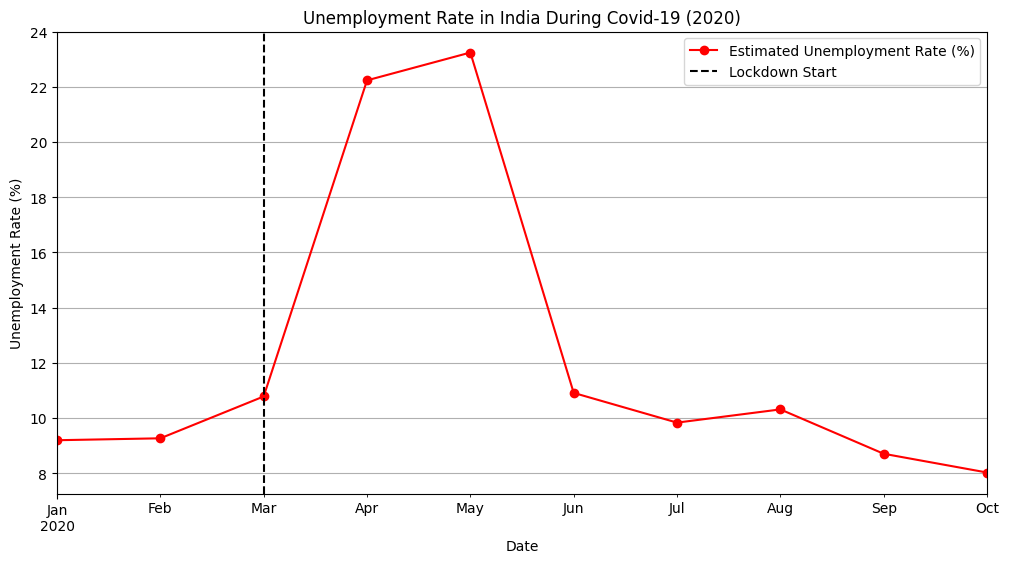

In [9]:
# Plot unemployment rate over time
plt.figure(figsize=(12, 6))
df2_grouped = df2.groupby('Date')['Estimated Unemployment Rate (%)'].mean()
df2_grouped.plot(kind='line', color='red', marker='o')
plt.title('Unemployment Rate in India During Covid-19 (2020)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.axvline(pd.to_datetime('2020-03-25'), color='black', linestyle='--', label='Lockdown Start')
plt.legend()
plt.grid(True)
plt.show()

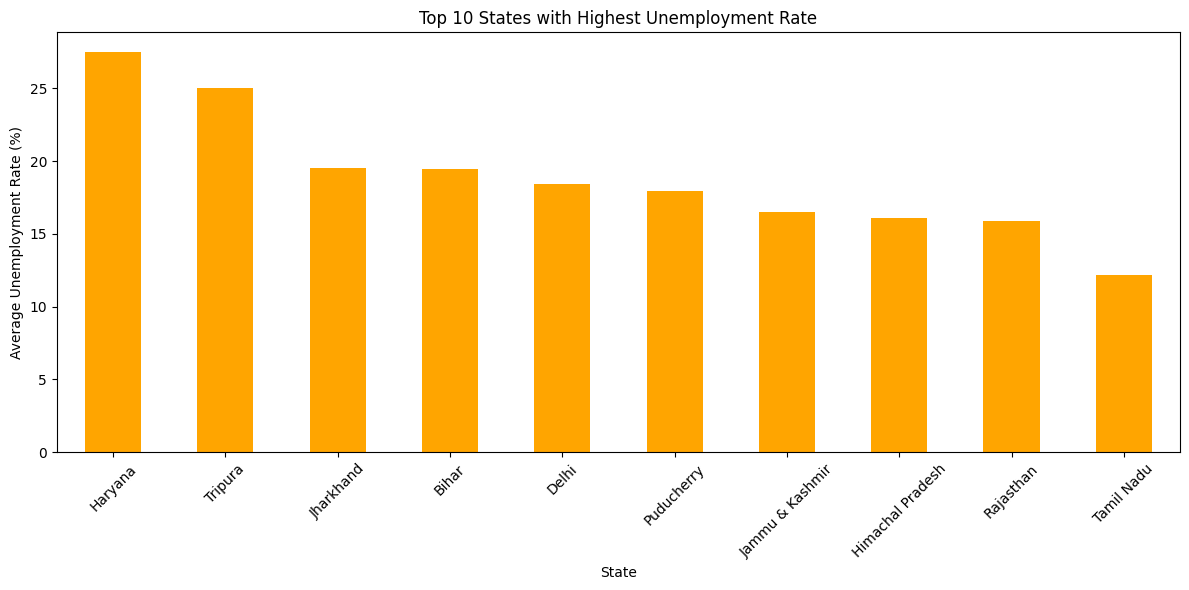

In [10]:
# Top 10 states with highest unemployment rate
plt.figure(figsize=(12, 6))
state_unemployment = df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)
state_unemployment.plot(kind='bar', color='orange')
plt.title('Top 10 States with Highest Unemployment Rate')
plt.xlabel('State')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

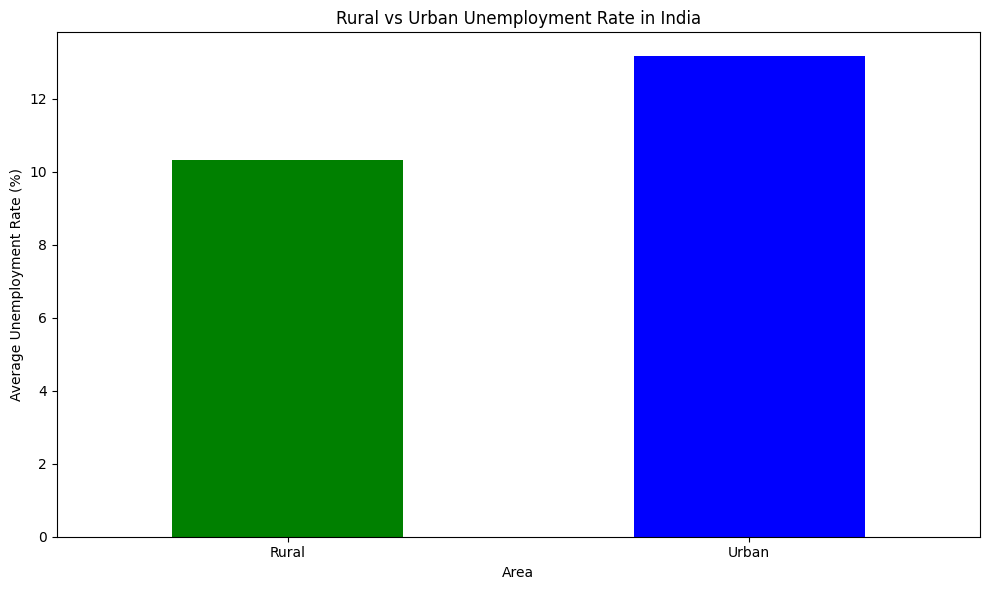

In [11]:
# Rural vs Urban unemployment comparison
plt.figure(figsize=(10, 6))
area_unemployment = df1.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
area_unemployment.plot(kind='bar', color=['green', 'blue'])
plt.title('Rural vs Urban Unemployment Rate in India')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

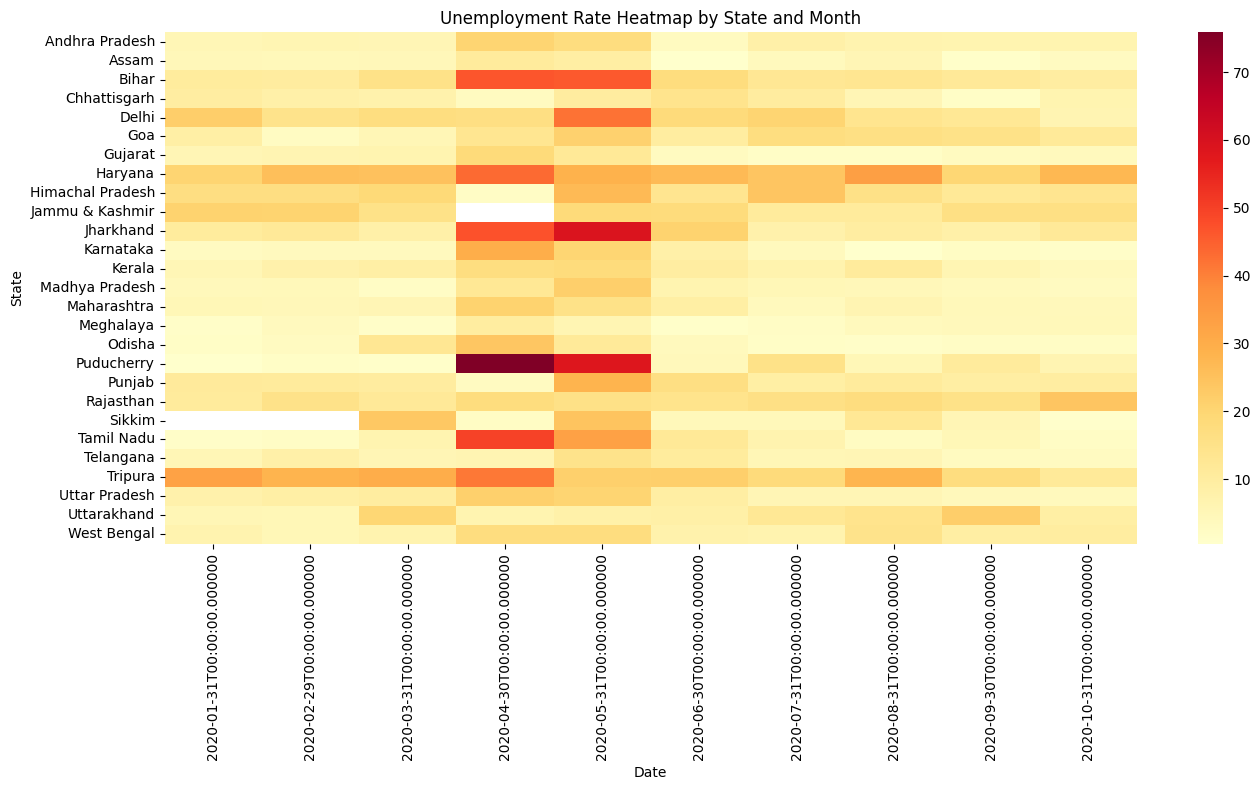

In [12]:
# Unemployment rate by region heatmap
plt.figure(figsize=(14, 8))
df2_pivot = df2.pivot_table(values='Estimated Unemployment Rate (%)', 
                             index='Region', 
                             columns='Date', 
                             aggfunc='mean')
sns.heatmap(df2_pivot, cmap='YlOrRd', annot=False)
plt.title('Unemployment Rate Heatmap by State and Month')
plt.xlabel('Date')
plt.ylabel('State')
plt.tight_layout()
plt.show()

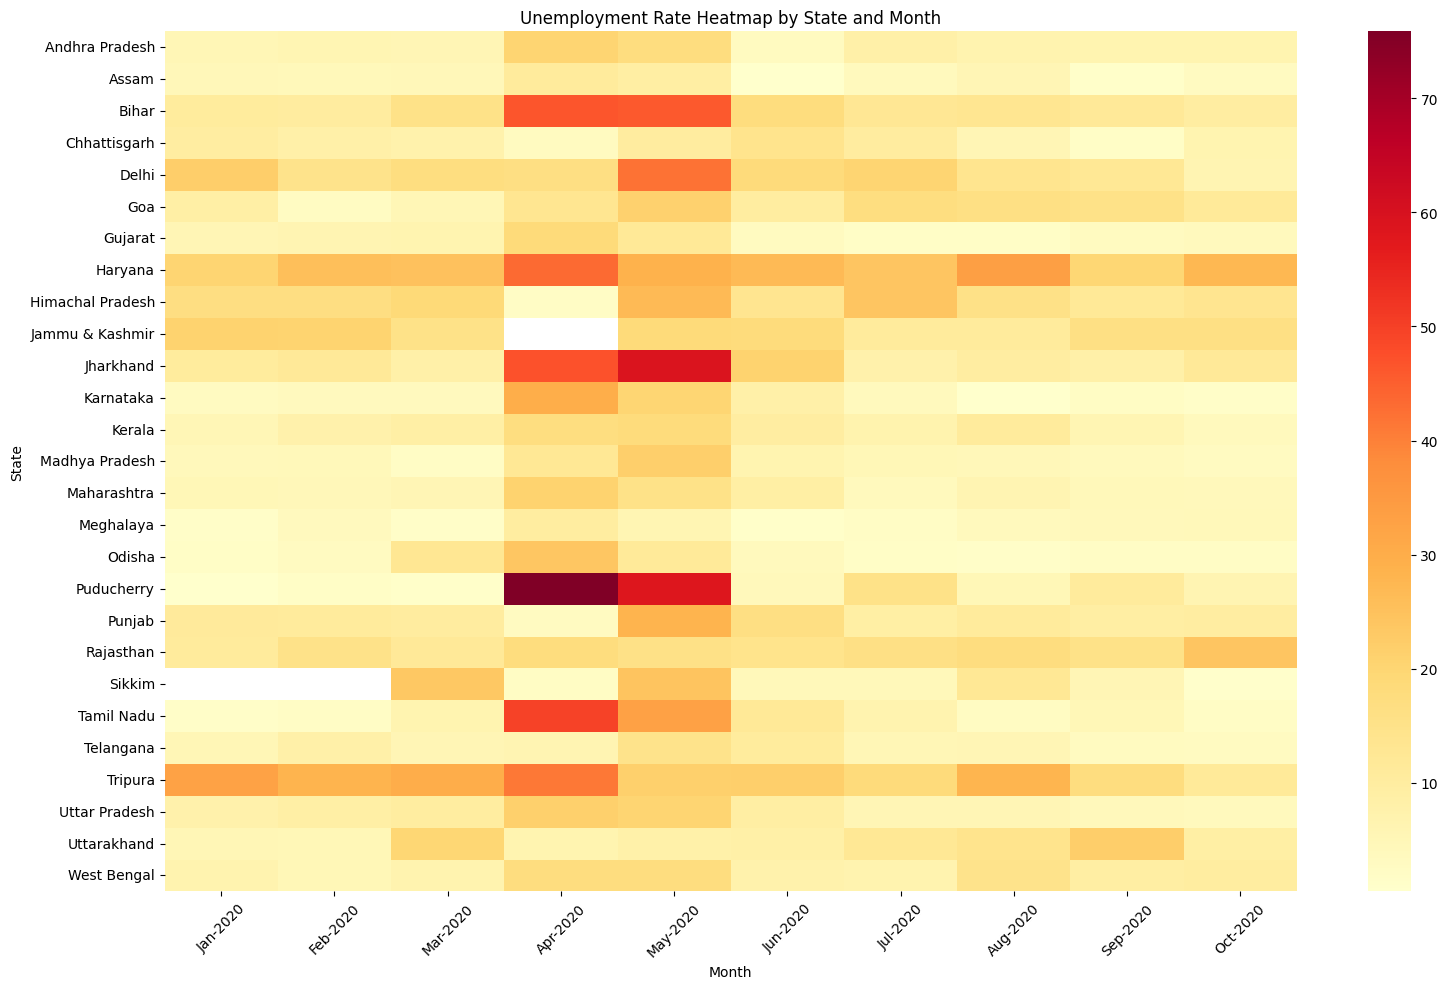

In [13]:
# Unemployment rate by region heatmap

plt.figure(figsize=(16, 10))

df2_pivot = df2.pivot_table(values='Estimated Unemployment Rate (%)', 

                             index='Region', 

                             columns='Date', 

                             aggfunc='mean')

# Format date columns to show only month

df2_pivot.columns = df2_pivot.columns.strftime('%b-%Y')

sns.heatmap(df2_pivot, cmap='YlOrRd', annot=False)

plt.title('Unemployment Rate Heatmap by State and Month')

plt.xlabel('Month')

plt.ylabel('State')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [15]:
# Summary insights
print("=== KEY INSIGHTS ===")
print("\nHighest Unemployment State:")
print(df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmax())

print("\nLowest Unemployment State:")
print(df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmin())

print("\nPeak Unemployment Month:")
print(df2.groupby('Date')['Estimated Unemployment Rate (%)'].mean().idxmax())

=== KEY INSIGHTS ===

Highest Unemployment State:
Haryana

Lowest Unemployment State:
Meghalaya

Peak Unemployment Month:
2020-05-31 00:00:00
